In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import drive

# Extract dataset
ZIP_PATH = '/content/drive/MyDrive/AgriGuard_Dataset.zip'

# Verifying dataset visibility before unpacking
if os.path.exists(ZIP_PATH):
    print(f"Success: Found archive asset at {ZIP_PATH}")
else:
    print(f"CRITICAL ERROR: Archive file not found. Ensure it is placed directly in your main 'My Drive' folder and named exactly 'AgriGuard_Dataset.zip'")

Success: Found archive asset at /content/drive/MyDrive/AgriGuard_Dataset.zip


In [3]:
print("Unpacking data onto local storage disk...")
# Extracts the files directly into the root /content directory
!unzip -q {ZIP_PATH} -d /content/

print("\n--- Verifying Extracted Folders ---")
contents = os.listdir('/content')
if 'datasets' in contents and 'agriguard_clean_working' in contents:
    print("SUCCESS: Data structure verified and ready for initialization.")
else:
    print("WARNING: Incomplete extraction. Current root contents:", contents)

Unpacking data onto local storage disk...

--- Verifying Extracted Folders ---
SUCCESS: Data structure verified and ready for initialization.


In [4]:
import os
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Setup paths on Colab fast storage
DATASETS_ROOT = '/content/datasets'
CSV_ROOT = '/content/agriguard_clean_working'
IMG_SIZE = 300
BATCH_SIZE = 32

# 1. Load Manifests
print("Loading data blueprints...")
train_m1 = pd.read_csv(f'{CSV_ROOT}/model1_train.csv')
val_m1   = pd.read_csv(f'{CSV_ROOT}/model1_val.csv')
test_m1  = pd.read_csv(f'{CSV_ROOT}/model1_test.csv')

train_m2 = pd.read_csv(f'{CSV_ROOT}/model2_train.csv')
val_m2   = pd.read_csv(f'{CSV_ROOT}/model2_val.csv')
test_m2  = pd.read_csv(f'{CSV_ROOT}/model2_test.csv')

print(f"M1 — Train: {len(train_m1)} | Val: {len(val_m1)} | Test: {len(test_m1)}")
print(f"M2 — Train: {len(train_m2)} | Val: {len(val_m2)} | Test: {len(test_m2)}")
print(f"M1 classes: {train_m1['label'].nunique()} | M2 classes: {train_m2['label'].nunique()}")

# 2. Setup Image Generators (Augmentation factory)
train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=40, width_shift_range=0.2, height_shift_range=0.2,
    shear_range=0.2, zoom_range=0.2, horizontal_flip=True, vertical_flip=True,
    brightness_range=[0.7, 1.3], fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)
print("Generators initialized successfully.")

Loading data blueprints...
M1 — Train: 15400 | Val: 3300 | Test: 3300
M2 — Train: 44790 | Val: 9598 | Test: 9598
M1 classes: 11 | M2 classes: 76
Generators initialized successfully.


In [16]:
import tensorflow as tf
import pandas as pd
from PIL import Image
import numpy as np

# 1. PATH CORRECTION CORNERSTONE
def fix_colab_paths(df):
    df = df.copy()
    df['filepath'] = df['filepath'].str.replace(r'C:\\Users\\mears\\Downloads\\datasets', '/content/datasets', regex=True)
    df['filepath'] = df['filepath'].str.replace('\\', '/', regex=False)
    return df

print("Converting paths from Windows to Colab Linux format...")
train_m1_fixed = fix_colab_paths(train_m1)
val_m1_fixed   = fix_colab_paths(val_m1)

# 2. ROBUST IMAGE LOADING VIA PIL (Prevents dimension dimension crashes)
def load_and_clean_image(file_path, class_label):
    def _parse_fn(path):
        try:
            # Open via PIL to automatically strip corrupt or nested dimensions
            with Image.open(path.numpy().decode('utf-8')) as img:
                img = img.convert('RGB')
                img = img.resize((IMG_SIZE, IMG_SIZE))
                return np.array(img, dtype=np.float32) / 255.0
        except Exception as e:
            # Fallback placeholder if an image is completely broken
            return np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)

    # Wrap the python function so tf.data can run it in parallel
    [image_tensor] = tf.py_function(_parse_fn, [file_path], [tf.float32])
    image_tensor.set_shape([IMG_SIZE, IMG_SIZE, 3])
    return image_tensor, class_label

# Augmentations running on the clean tensors
def apply_training_augmentations(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    return image, label

print("\n=== ENCODING LABELS & CONFIGURING TF.DATA ENGINE ===")
m1_train_labels = pd.get_dummies(train_m1_fixed['label']).values
m1_val_labels = pd.get_dummies(val_m1_fixed['label']).values

# 3. ASSEMBLE PRODUCTION DATA STREAMS
m1_train_dataset = tf.data.Dataset.from_tensor_slices((train_m1_fixed['filepath'].values, m1_train_labels))
m1_train_dataset = m1_train_dataset.shuffle(buffer_size=1000, seed=42)
# Load and clean first using our robust PIL parser
m1_train_dataset = m1_train_dataset.map(load_and_clean_image, num_parallel_calls=tf.data.AUTOTUNE)
m1_train_dataset = m1_train_dataset.map(apply_training_augmentations, num_parallel_calls=tf.data.AUTOTUNE)
m1_train_dataset = m1_train_dataset.batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

m1_val_dataset = tf.data.Dataset.from_tensor_slices((val_m1_fixed['filepath'].values, m1_val_labels))
m1_val_dataset = m1_val_dataset.map(load_and_clean_image, num_parallel_calls=tf.data.AUTOTUNE)
m1_val_dataset = m1_val_dataset.batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

print("High-speed robust data streams successfully mapped. Memory is safe.")

Converting paths from Windows to Colab Linux format...

=== ENCODING LABELS & CONFIGURING TF.DATA ENGINE ===
High-speed robust data streams successfully mapped. Memory is safe.


In [17]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight

print("=== INITIALIZING MODEL 1 (CROP FIREWALL HEAD) ===")

tf.keras.backend.clear_session()

# 1. CLASS WEIGHTS OPTIMIZATION
crop_training_labels = train_m1_fixed['label'].values
unique_crop_identifiers = np.unique(crop_training_labels)

calculated_crop_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_crop_identifiers,
    y=crop_training_labels
)
crop_class_weights_map = dict(enumerate(calculated_crop_weights))

# 2. ARCHITECTURE COMPOSITION
efficientnet_backbone = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
efficientnet_backbone.trainable = True

network_features = efficientnet_backbone.output
pooled_features = GlobalAveragePooling2D()(network_features)
regularized_features = Dropout(rate=0.3, name="overfitting_guard")(pooled_features)
network_predictions = Dense(
    units=11,
    activation='softmax',
    name='crop_classification_layer'
)(regularized_features)

model1 = Model(inputs=efficientnet_backbone.input, outputs=network_predictions)

# 3. PIPELINE COMPILATION
model1.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

total_trainable_parameters = sum([tf.size(weights_tensor).numpy() for weights_tensor in model1.trainable_weights])
print(f"Total Trainable Backbone & Head Parameters: {total_trainable_parameters:,}")
print("Model 1 initialization complete. Ready for tracking callbacks execution.")

=== INITIALIZING MODEL 1 (CROP FIREWALL HEAD) ===
Total Trainable Backbone & Head Parameters: 10,713,139
Model 1 initialization complete. Ready for tracking callbacks execution.


In [18]:
import os
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("=== CONFIGURING OVERSEER TRACKING WORKFLOW ===")

# Create a secure home directory for our model weights on the cloud disk
checkpoint_storage_path = "/content/model_checkpoints"
os.makedirs(checkpoint_storage_path, exist_ok=True)


# BACKEND MONITORING HOOKS (PRODUCTION SETUP)


# 1. Automatic Save System: Captures and saves only when validation loss hits a new low
model_checkpoint_callback = ModelCheckpoint(
    filepath=os.path.join(checkpoint_storage_path, "AgriGuard_Model1_Best.keras"),
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

# 2. Resource Protection: Safely kills the execution if the model stops improving for 5 epochs
early_stopping_callback = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 3. Optimization Brake: Cuts learning rate in half if training hits a difficult plateau
learning_rate_reduction_callback = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Bundle our hooks into a single execution manifest
active_callbacks_list = [
    model_checkpoint_callback,
    early_stopping_callback,
    learning_rate_reduction_callback
]


# PIPELINE EXECUTION ENGINE (TRAINING PASS)

TOTAL_TRAINING_EPOCHS = 20

print(f"\nIgniting the tf.data optimized engine across {TOTAL_TRAINING_EPOCHS} epochs...")
training_history_model1 = model1.fit(
    m1_train_dataset,  # Streaming our high-speed, prefetched RAM dataset
    epochs=TOTAL_TRAINING_EPOCHS,
    validation_data=m1_val_dataset,
    class_weight=crop_class_weights_map,  # Balancing out variations algorithmically
    callbacks=active_callbacks_list
)

print("\nModel 1 Training Phase Finished Successfully!")

=== CONFIGURING OVERSEER TRACKING WORKFLOW ===

Igniting the tf.data optimized engine across 20 epochs...
Epoch 1/20
463/482 ━━━━━━━━━━━━━━━━━━━━ 5s 266ms/step - accuracy: 0.7627 - loss: 0.8263

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py:887: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(


482/482 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.7679 - loss: 0.8086
Epoch 1: val_loss improved from None to 1.27845, saving model to /content/model_checkpoints/AgriGuard_Model1_Best.keras

Epoch 1: finished saving model to /content/model_checkpoints/AgriGuard_Model1_Best.keras
482/482 ━━━━━━━━━━━━━━━━━━━━ 364s 508ms/step - accuracy: 0.8974 - loss: 0.3727 - val_accuracy: 0.5518 - val_loss: 1.2784 - learning_rate: 1.0000e-04
Epoch 2/20
482/482 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.9730 - loss: 0.0845
Epoch 2: val_loss improved from 1.27845 to 0.26374, saving model to /content/model_checkpoints/AgriGuard_Model1_Best.keras

Epoch 2: finished saving model to /content/model_checkpoints/AgriGuard_Model1_Best.keras
482/482 ━━━━━━━━━━━━━━━━━━━━ 146s 303ms/step - accuracy: 0.9786 - loss: 0.0694 - val_accuracy: 0.9164 - val_loss: 0.2637 - learning_rate: 1.0000e-04
Epoch 3/20
481/482 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.9870 - loss: 0.0453
Epoch 3: val_loss did not 

=== GENERATING PERFORMANCE EVALUATION METRICS ===


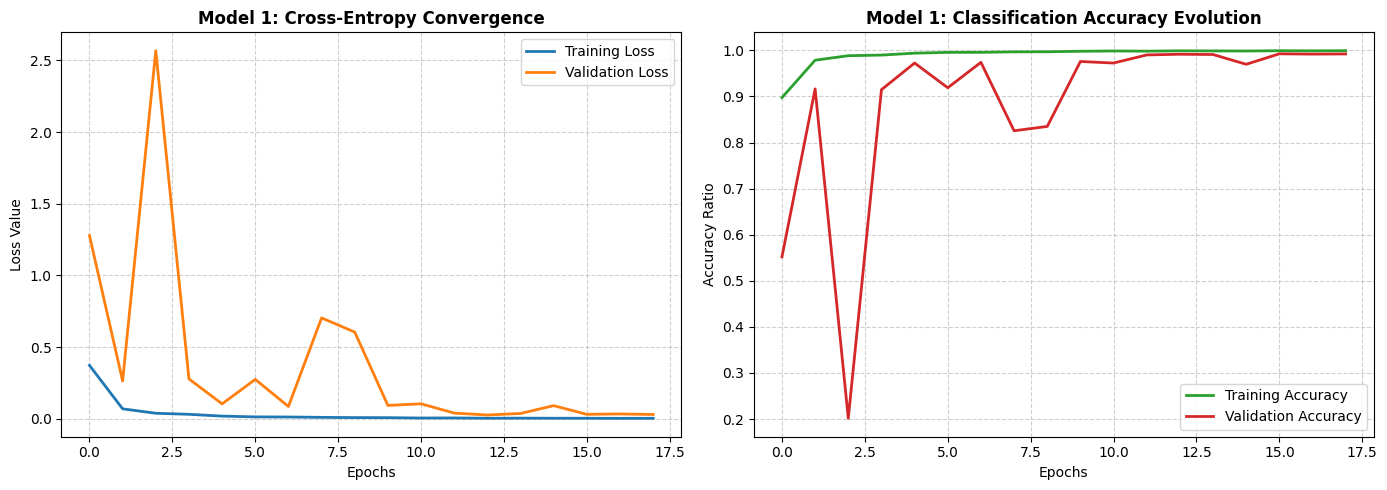


Harvesting predictions from validation dataset stream (this may take a moment)...


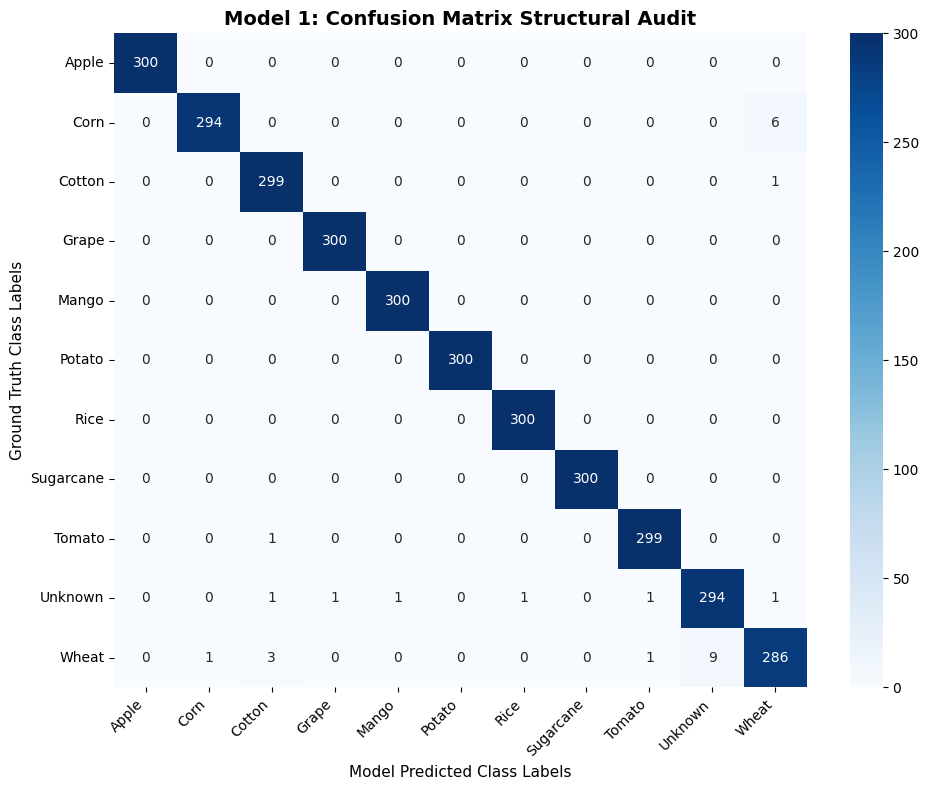


=== SYSTEM CLASSIFICATION AUDIT REPORT ===
              precision    recall  f1-score   support

       Apple     1.0000    1.0000    1.0000       300
        Corn     0.9966    0.9800    0.9882       300
      Cotton     0.9836    0.9967    0.9901       300
       Grape     0.9967    1.0000    0.9983       300
       Mango     0.9967    1.0000    0.9983       300
      Potato     1.0000    1.0000    1.0000       300
        Rice     0.9967    1.0000    0.9983       300
   Sugarcane     1.0000    1.0000    1.0000       300
      Tomato     0.9934    0.9967    0.9950       300
     Unknown     0.9703    0.9800    0.9751       300
       Wheat     0.9728    0.9533    0.9630       300

    accuracy                         0.9915      3300
   macro avg     0.9915    0.9915    0.9915      3300
weighted avg     0.9915    0.9915    0.9915      3300



In [19]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("=== GENERATING PERFORMANCE EVALUATION METRICS ===")


# 1. PLOT METRIC TRAJECTORY CURVES

plt.figure(figsize=(14, 5))

# Plot Cross-Entropy Loss Curve
plt.subplot(1, 2, 1)
plt.plot(training_history_model1.history['loss'], label='Training Loss', color='#1f77b4', linewidth=2)
plt.plot(training_history_model1.history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)
plt.title('Model 1: Cross-Entropy Convergence', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss Value', fontsize=10)
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Accuracy Evolution Curve
plt.subplot(1, 2, 2)
plt.plot(training_history_model1.history['accuracy'], label='Training Accuracy', color='#2ca02c', linewidth=2)
plt.plot(training_history_model1.history['val_accuracy'], label='Validation Accuracy', color='#d62728', linewidth=2)
plt.title('Model 1: Classification Accuracy Evolution', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Accuracy Ratio', fontsize=10)
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


# 2. EXTRACT TRUE LABELS AND PREDICTIONS FROM THE TF.DATA STREAM

print("\nHarvesting predictions from validation dataset stream (this may take a moment)...")

true_labels_list = []
predicted_labels_list = []

# Unpack the prefetched validation dataset batches sequentially
for images_batch, labels_batch in m1_val_dataset:
    batch_predictions = model1.predict(images_batch, verbose=0)

    # Convert one-hot vectors into explicit class indices
    true_labels_list.extend(np.argmax(labels_batch.numpy(), axis=1))
    predicted_labels_list.extend(np.argmax(batch_predictions, axis=1))

y_true = np.array(true_labels_list)
y_pred = np.array(predicted_labels_list)

# Retrieve ordered text labels from our dummies format
class_labels_ordered = sorted(train_m1_fixed['label'].unique())


# 3. PLOT CONFUSION MATRIX HIERARCHY

computed_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    computed_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels_ordered,
    yticklabels=class_labels_ordered
)
plt.title('Model 1: Confusion Matrix Structural Audit', fontsize=14, fontweight='bold')
plt.ylabel('Ground Truth Class Labels', fontsize=11)
plt.xlabel('Model Predicted Class Labels', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# 4. PRINT COMPREHENSIVE CLASSIFICATION REPORT

print("\n=== SYSTEM CLASSIFICATION AUDIT REPORT ===")
print(classification_report(y_true, y_pred, target_names=class_labels_ordered, digits=4))

In [20]:
import shutil
import os

print("=== EXPORTING MODEL 1 TO PERMANENT STORAGE ===")

# Define the source file and permanent destination path on your Google Drive
SOURCE_CHECKPOINT = "/content/model_checkpoints/AgriGuard_Model1_Best.keras"
DRIVE_DESTINATION_DIR = "/content/drive/MyDrive/AgriGuard/Models"
DRIVE_DESTINATION_FILE = os.path.join(DRIVE_DESTINATION_DIR, "AgriGuard_Model1_Final.keras")

# Create the directory on Google Drive if it doesn't exist yet
os.makedirs(DRIVE_DESTINATION_DIR, exist_ok=True)

try:
    if os.path.exists(SOURCE_CHECKPOINT):
        print(f"Compressing and copying model artifact to Google Drive...")
        shutil.copy(SOURCE_CHECKPOINT, DRIVE_DESTINATION_FILE)
        print(f" SUCCESSFULLY EXPORTED!")
        print(f"Saved to: {DRIVE_DESTINATION_FILE}")
        print(f"File Size: {os.path.getsize(DRIVE_DESTINATION_FILE) / (1024*1024):.2f} MB")
    else:
        print("CRITICAL ERROR: Best checkpoint file not found in local workspace.")
except Exception as error_message:
    print(f"Export failed: {str(error_message)}")

=== EXPORTING MODEL 1 TO PERMANENT STORAGE ===
Compressing and copying model artifact to Google Drive...
 SUCCESSFULLY EXPORTED!
Saved to: /content/drive/MyDrive/AgriGuard/Models/AgriGuard_Model1_Final.keras
File Size: 124.45 MB


In [21]:
import tensorflow as tf
import pandas as pd

print("=== GENERATING HIGH-SPEED STREAM PIPELINES FOR MODEL 2 ===")


# 1. CATEGORICAL LABEL ENCODING

# We convert our text disease strings into structured one-hot matrices
# so the neural network can map them to its final 76 output nodes.
disease_train_labels = pd.get_dummies(train_m2_fixed['label']).values
disease_val_labels = pd.get_dummies(val_m2_fixed['label']).values


# 2. TRAINING STREAM COMPOSITION

# Slicing the paths and arrays directly into a multi-threaded tf.data stream.
# We increase the shuffle buffer size to 2,000 to mix the 44,790 files evenly.
m2_train_dataset = tf.data.Dataset.from_tensor_slices((train_m2_fixed['filepath'].values, disease_train_labels))
m2_train_dataset = m2_train_dataset.shuffle(buffer_size=2000, seed=42)

# Run our robust Pillow loading function first to strip any corrupt data on the fly
m2_train_dataset = m2_train_dataset.map(load_and_clean_image, num_parallel_calls=tf.data.AUTOTUNE)
m2_train_dataset = m2_train_dataset.map(apply_training_augmentations, num_parallel_calls=tf.data.AUTOTUNE)

# Batch the dataset and prefetch future arrays directly into the A100 memory cache
m2_train_dataset = m2_train_dataset.batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)


# 3. VALIDATION STREAM COMPOSITION

# A pure, unaugmented stream specifically to gauge real-world accuracy.
m2_val_dataset = tf.data.Dataset.from_tensor_slices((val_m2_fixed['filepath'].values, disease_val_labels))
m2_val_dataset = m2_val_dataset.map(load_and_clean_image, num_parallel_calls=tf.data.AUTOTUNE)
m2_val_dataset = m2_val_dataset.batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

print("Model 2 high-speed training and validation streams are officially live in cache!")

=== GENERATING HIGH-SPEED STREAM PIPELINES FOR MODEL 2 ===
Model 2 high-speed training and validation streams are officially live in cache!


In [22]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight

print("=== INITIALIZING MODEL 2 (76-CLASS DISEASE ENGINE) ===")

# Wipe the internal Keras graph memory state clear to prevent memory leaks on the A100
tf.keras.backend.clear_session()


# 1. CLASS WEIGHTS OPTIMIZATION

# With 76 classes, some rare plant diseases will naturally have fewer samples.
# Calculating algorithmic class weights ensures the loss function penalizes
# the model more heavily if it gets a rare class wrong.
disease_training_labels = train_m2_fixed['label'].values
unique_disease_identifiers = np.unique(disease_training_labels)

calculated_disease_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_disease_identifiers,
    y=disease_training_labels
)
# Map the weights directly to integer indices for Keras processing compatibility
disease_class_weights_map = dict(enumerate(calculated_disease_weights))


# 2. ARCHITECTURE COMPOSITION (TRANSFER LEARNING DEPLOYMENT)

# Initializing the backbone fully unfrozen with pre-trained weights.
# A gentle learning rate of 1e-4 allows it to safely master the subtle variations
# between 76 visual conditions without losing its foundational shapes knowledge.
efficientnet_backbone_m2 = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
efficientnet_backbone_m2.trainable = True

# Connect a production-grade classification head onto the feature outputs
network_features_m2 = efficientnet_backbone_m2.output
pooled_features_m2 = GlobalAveragePooling2D()(network_features_m2)
regularized_features_m2 = Dropout(rate=0.3, name="overfitting_guard_m2")(pooled_features_m2)

# Expanding our classification layer to house exactly 76 output nodes with a softmax gate
network_predictions_m2 = Dense(
    units=76,
    activation='softmax',
    name='disease_classification_layer'
)(regularized_features_m2)

model2 = Model(inputs=efficientnet_backbone_m2.input, outputs=network_predictions_m2)


# 3. PIPELINE COMPILATION

model2.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Conduct a quick structural verification count
total_trainable_parameters_m2 = sum([tf.size(weights_tensor).numpy() for weights_tensor in model2.trainable_weights])
print(f"Total Trainable Backbone & Head Parameters: {total_trainable_parameters_m2:,}")
print("Model 2 initialization complete. Ready for tracking callbacks execution.")

=== INITIALIZING MODEL 2 (76-CLASS DISEASE ENGINE) ===
Total Trainable Backbone & Head Parameters: 10,813,044
Model 2 initialization complete. Ready for tracking callbacks execution.


In [23]:
import os
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("=== CONFIGURING OVERSEER TRACKING WORKFLOW FOR MODEL 2 ===")

# Establish a targeted subdirectory for Model 2's specific weight checkpoints
checkpoint_storage_path = "/content/model_checkpoints"
os.makedirs(checkpoint_storage_path, exist_ok=True)


# PRODUCTION-GRADE CALLBACK HOOKS


# 1. Automatic Save System: Actively locks down weights when validation loss drops
model_checkpoint_callback_m2 = ModelCheckpoint(
    filepath=os.path.join(checkpoint_storage_path, "AgriGuard_Model2_Best.keras"),
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

# 2. Early Warning Brake: Automatically ends training if val_loss flatlines for 5 epochs
early_stopping_callback_m2 = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 3. Dynamic Learning Rate Brake: Drops the optimizer speed if performance hits a wall
learning_rate_reduction_callback_m2 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Bundle our monitoring layers into a clean execution manifest
active_callbacks_list_m2 = [
    model_checkpoint_callback_m2,
    early_stopping_callback_m2,
    learning_rate_reduction_callback_m2
]


# ACTIVE TRAINING EXECUTION PASS

TOTAL_TRAINING_EPOCHS_M2 = 20

print(f"\nIgniting the tf.data optimized engine across {TOTAL_TRAINING_EPOCHS_M2} epochs...")
training_history_model2 = model2.fit(
    m2_train_dataset,  # Pumping our high-speed prefetched dataset straight to the A100
    epochs=TOTAL_TRAINING_EPOCHS_M2,
    validation_data=m2_val_dataset,
    class_weight=disease_class_weights_map,  # Balancing out rare vs common diseases
    callbacks=active_callbacks_list_m2
)

print("\nModel 2 Training Phase Finished Successfully!")

=== CONFIGURING OVERSEER TRACKING WORKFLOW FOR MODEL 2 ===

Igniting the tf.data optimized engine across 20 epochs...
Epoch 1/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.5638 - loss: 1.8650
Epoch 1: val_loss improved from None to 0.73607, saving model to /content/model_checkpoints/AgriGuard_Model2_Best.keras

Epoch 1: finished saving model to /content/model_checkpoints/AgriGuard_Model2_Best.keras
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 735s 436ms/step - accuracy: 0.7340 - loss: 1.0338 - val_accuracy: 0.7745 - val_loss: 0.7361 - learning_rate: 1.0000e-04
Epoch 2/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.8762 - loss: 0.3923
Epoch 2: val_loss did not improve from 0.73607
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 447s 319ms/step - accuracy: 0.8887 - loss: 0.3511 - val_accuracy: 0.1103 - val_loss: 4.0525 - learning_rate: 1.0000e-04
Epoch 3/20
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.9146 - loss: 0.2637
Epoch 3: val_loss did not improve from 0.73607

Epoch

=== GENERATING MODEL 2 EVALUATION GRAPH WORKFLOW ===


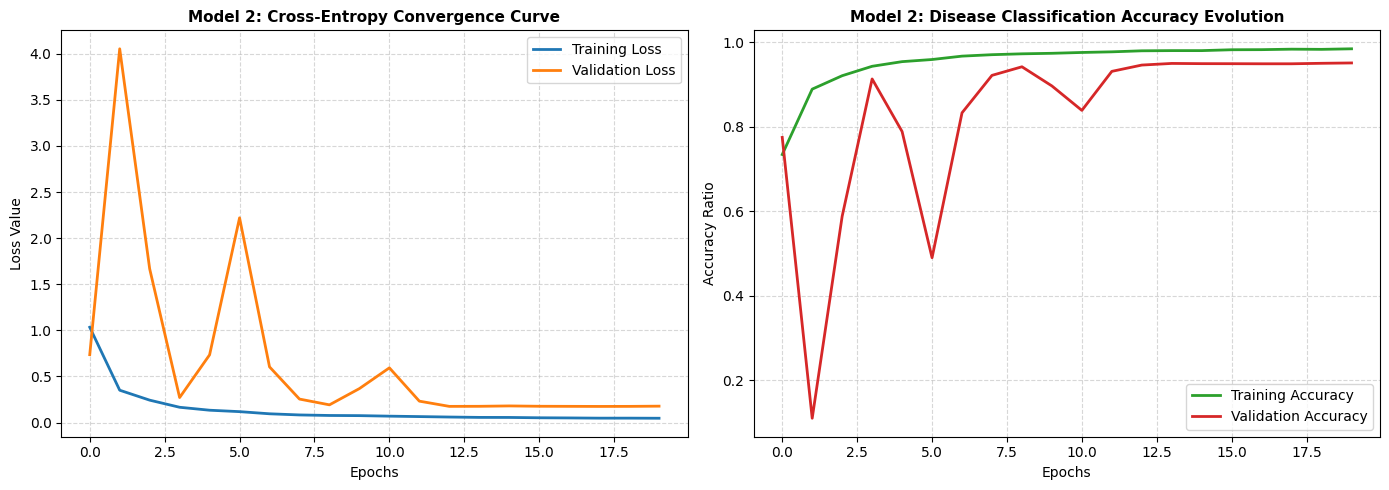


Extracting tensor predictions across the validation stream (this will take a moment)...

=== SYSTEM DISEASE CLASSIFICATION REPORT ===
                                 precision    recall  f1-score   support

            Anthracnose (Mango)     0.9926    1.0000    0.9963       135
                Aphids (Cotton)     1.0000    0.9933    0.9967       150
                 Aphids (Wheat)     0.9416    0.8836    0.9117       146
             Apple Scab (Apple)     1.0000    1.0000    1.0000       150
      Bacterial Blight (Cotton)     1.0000    0.9933    0.9967       150
        Bacterial Blight (Rice)     0.9684    0.9583    0.9634        96
   Bacterial Blight (Sugarcane)     0.9836    1.0000    0.9917        60
       Bacterial Canker (Mango)     1.0000    1.0000    1.0000       135
        Bacterial Spot (Tomato)     0.9597    0.9533    0.9565       150
   Banded Chlorosis (Sugarcane)     0.8356    0.8592    0.8472        71
              Black Rot (Apple)     1.0000    1.0000    1.000

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("=== GENERATING MODEL 2 EVALUATION GRAPH WORKFLOW ===")

# 1. PLOT TRAINING HISTORY CURVES

plt.figure(figsize=(14, 5))

# Plot Cross-Entropy Convergence Matrix
plt.subplot(1, 2, 1)
plt.plot(training_history_model2.history['loss'], label='Training Loss', color='#1f77b4', linewidth=2)
plt.plot(training_history_model2.history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)
plt.title('Model 2: Cross-Entropy Convergence Curve', fontsize=11, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss Value', fontsize=10)
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)

# Plot Classification Accuracy Evolution Matrix
plt.subplot(1, 2, 2)
plt.plot(training_history_model2.history['accuracy'], label='Training Accuracy', color='#2ca02c', linewidth=2)
plt.plot(training_history_model2.history['val_accuracy'], label='Validation Accuracy', color='#d62728', linewidth=2)
plt.title('Model 2: Disease Classification Accuracy Evolution', fontsize=11, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Accuracy Ratio', fontsize=10)
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 2. HARVEST PREDICTIONS FROM THE LARGE DATASTREAM

print("\nExtracting tensor predictions across the validation stream (this will take a moment)...")

m2_true_labels = []
m2_predicted_labels = []

# Loop through our prefetched high-speed stream batches sequentially
for images_batch, labels_batch in m2_val_dataset:
    batch_predictions = model2.predict(images_batch, verbose=0)

    # Compress one-hot arrays down to raw integer indices
    m2_true_labels.extend(np.argmax(labels_batch.numpy(), axis=1))
    m2_predicted_labels.extend(np.argmax(batch_predictions, axis=1))

y_true_m2 = np.array(m2_true_labels)
y_pred_m2 = np.array(m2_predicted_labels)

# Extract alphabetized text directories for clear diagnostic reporting
m2_class_labels_ordered = sorted(train_m2_fixed['label'].unique())


# 3. PRINT SYSTEM CLASSIFICATION AUDIT REPORT

print("\n=== SYSTEM DISEASE CLASSIFICATION REPORT ===")
print(classification_report(y_true_m2, y_pred_m2, target_names=m2_class_labels_ordered, digits=4))

=== COMPUTING MODEL 2 VISUAL HEATMAP STRUCTURE ===


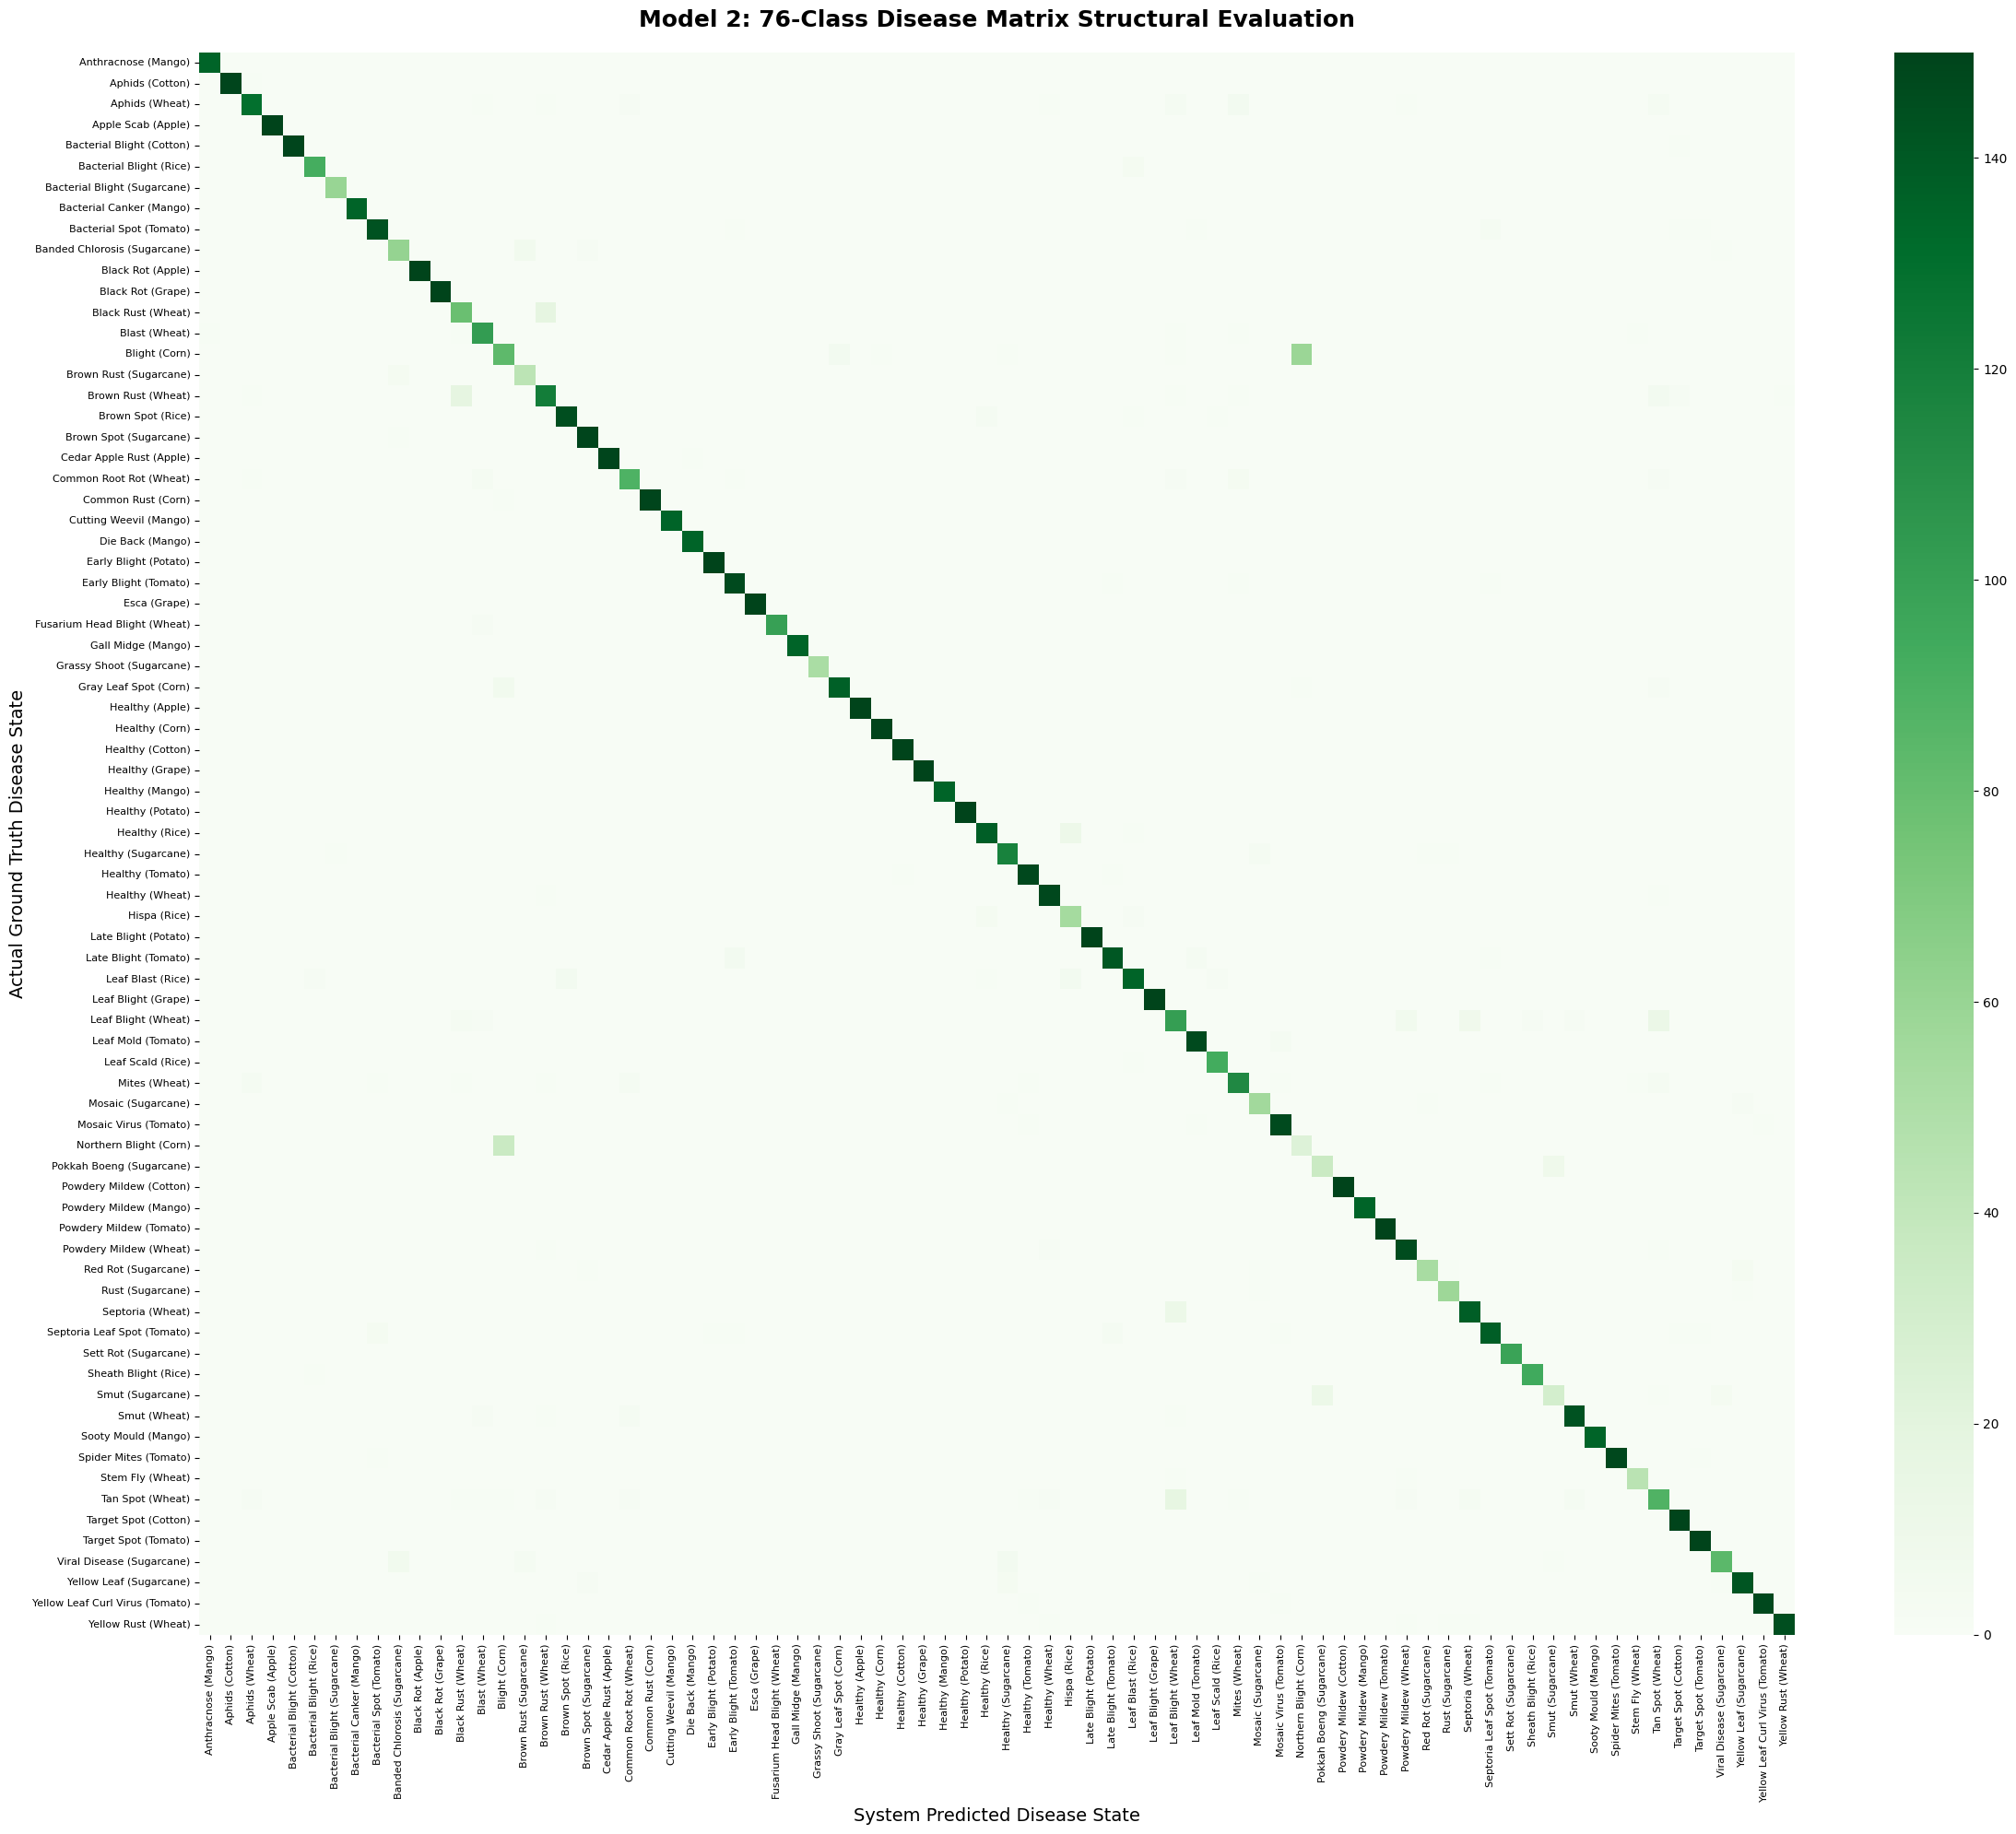

Matrix visual generation complete. Ready for final cloud archive.


In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("=== COMPUTING MODEL 2 VISUAL HEATMAP STRUCTURE ===")

# Compute the raw classification intersections across all 76 dimensions
computed_matrix_m2 = confusion_matrix(y_true_m2, y_pred_m2)

# Set up a massive figure space so the 76 text labels don't bunch up or overlap
plt.figure(figsize=(24, 20))

sns.heatmap(
    computed_matrix_m2,
    annot=False,          # Set to False because 76x76 numbers inside boxes become unreadable
    cmap='Greens',        # Using green palette to align with AgriGuard branding themes
    xticklabels=m2_class_labels_ordered,
    yticklabels=m2_class_labels_ordered
)

plt.title('Model 2: 76-Class Disease Matrix Structural Evaluation', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Actual Ground Truth Disease State', fontsize=14)
plt.xlabel('System Predicted Disease State', fontsize=14)

# Rotate labels to ensure clean reading boundaries
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

print("Matrix visual generation complete. Ready for final cloud archive.")

In [26]:
import shutil
import os

print("=== EXPORTING MODEL 2 TO PERMANENT STORAGE ===")

# Define source checkpoint path and permanent destination path on your Google Drive
SOURCE_CHECKPOINT_M2 = "/content/model_checkpoints/AgriGuard_Model2_Best.keras"
DRIVE_DESTINATION_DIR_M2 = "/content/drive/MyDrive/AgriGuard/Models"
DRIVE_DESTINATION_FILE_M2 = os.path.join(DRIVE_DESTINATION_DIR_M2, "AgriGuard_Model2_Final.keras")

# Create the directory structure on your Drive if it isn't built yet
os.makedirs(DRIVE_DESTINATION_DIR_M2, exist_ok=True)

try:
    if os.path.exists(SOURCE_CHECKPOINT_M2):
        print("Compressing and copying Model 2 artifact to Google Drive...")
        shutil.copy(SOURCE_CHECKPOINT_M2, DRIVE_DESTINATION_FILE_M2)
        print(" SUCCESSFULLY EXPORTED!")
        print(f"Saved to: {DRIVE_DESTINATION_FILE_M2}")
        print(f"File Size: {os.path.getsize(DRIVE_DESTINATION_FILE_M2) / (1024*1024):.2f} MB")
    else:
        print("CRITICAL ERROR: Model 2 best checkpoint file not found in local workspace.")
except Exception as error_message:
    print(f"Export failed: {str(error_message)}")

=== EXPORTING MODEL 2 TO PERMANENT STORAGE ===
Compressing and copying Model 2 artifact to Google Drive...
 SUCCESSFULLY EXPORTED!
Saved to: /content/drive/MyDrive/AgriGuard/Models/AgriGuard_Model2_Final.keras
File Size: 125.59 MB


In [27]:
import json
import os

print("=== GENERATING CLASS MAPPING ARTIFACTS ===")

# Define the permanent home directory for our config mappings
mapping_destination_dir = "/content/drive/MyDrive/AgriGuard/Models"
os.makedirs(mapping_destination_dir, exist_ok=True)


# 1. GENERATE MODEL 1 MAPPING (11 Crop Classes)

# Extract alphabetized text labels exactly how pd.get_dummies ordered them
m1_classes = sorted(train_m1_fixed['label'].unique())

# Create a clean dictionary mapping the integer index to the text string
model1_mapping = {int(index): str(label) for index, label in enumerate(m1_classes)}

m1_json_path = os.path.join(mapping_destination_dir, "model1_crop_mapping.json")
with open(m1_json_path, 'w', encoding='utf-8') as f:
    json.dump(model1_mapping, f, indent=4, ensure_ascii=False)

print(f"Successfully exported Model 1 mapping ({len(model1_mapping)} classes) to Drive.")


# 2. GENERATE MODEL 2 MAPPING (76 Disease Classes)

# Extract alphabetized text labels exactly how pd.get_dummies ordered them for Model 2
m2_classes = sorted(train_m2_fixed['label'].unique())

# Create a clean dictionary mapping the integer index to the text string
model2_mapping = {int(index): str(label) for index, label in enumerate(m2_classes)}

m2_json_path = os.path.join(mapping_destination_dir, "model2_disease_mapping.json")
with open(m2_json_path, 'w', encoding='utf-8') as f:
    json.dump(model2_mapping, f, indent=4, ensure_ascii=False)

print(f"Successfully exported Model 2 mapping ({len(model2_mapping)} classes) to Drive.")
print("\n All application config mappings are permanently secured!")

=== GENERATING CLASS MAPPING ARTIFACTS ===
Successfully exported Model 1 mapping (11 classes) to Drive.
Successfully exported Model 2 mapping (76 classes) to Drive.

 All application config mappings are permanently secured!
